<a href="https://colab.research.google.com/github/OmarFarukNoman/Into-to-Machine-Learning/blob/main/Homework-6/Problem_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulation time (Neural Network): 1.10 seconds
Total number of trainable parameters (Neural Network): 4626

Losses and Accuracies (Neural Network)-

Final Training Loss:      0.1084
Final Validation Loss:    0.1095
Final Training Accuracy:  0.9803
Final Validation Accuracy:0.9823

Confusion Matrix values (Neural Network)-

[[43  1]
 [ 1 68]]

True Negative=43
False Positive=1
False Negative=1
True Positive=68

Evaluation Metrics (Neural Network)-

Accuracy:  0.9823
Precision: 0.9855
Recall:    0.9855
F1 Score:  0.9855

Evaluation Metrics (Logistic Regression)-

Accuracy:  0.9646
Precision: 0.9710
Recall:    0.9710
F1 Score:  0.9710

Evaluation Metrics (SVM, RBF)-

Accuracy:  0.9823
Precision: 1.0000
Recall:    0.9710
F1 Score:  0.9853

Model Comparison
Model                       Accuracy    Precision     Recall   F1-Score
----------------------------------------------------------------------
Neural Network                0.9823       0.9855     0.9855     0.9855
Logistic Regression   

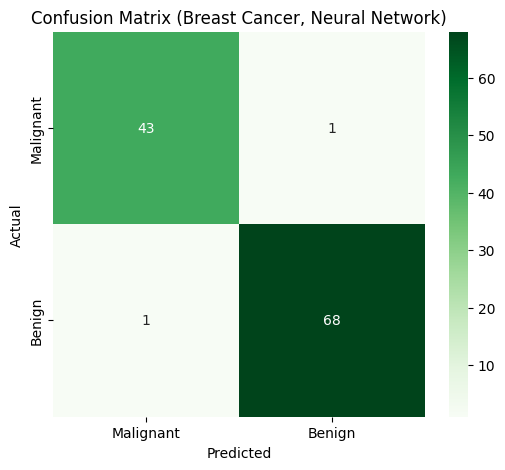

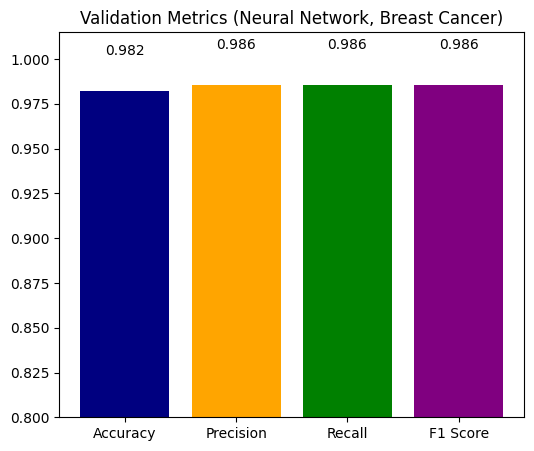

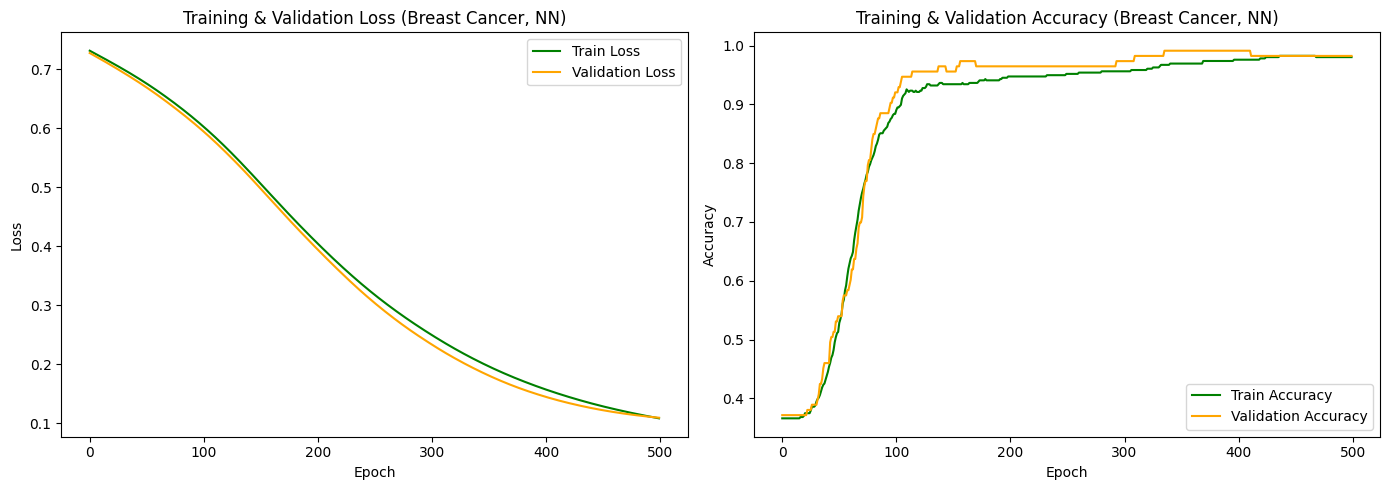

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import time

# We're using cancer dataset from sci-kit learn for HW6
data = load_breast_cancer()
X_in = data.data
y_out = data.target

# Convert to PyTorch tensors
t_X_in = torch.FloatTensor(X_in)
t_y_out = torch.LongTensor(y_out)

# I've splited the dataset (80% training and 20% validation)
torch.manual_seed(0)  # for reproducibility
n_samples = t_X_in.shape[0]
n_val = int(0.2 * n_samples)

# Random permutation
shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]  # first 80%
val_indices   = shuffled_indices[-n_val:]  # last 20%

train_t_X_in = t_X_in[train_indices]
train_t_y_out = t_y_out[train_indices]
val_t_X_in = t_X_in[val_indices]
val_t_y_out = t_y_out[val_indices]

# Standardization
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_t_X_in.numpy())
val_scaled   = scaler.transform(val_t_X_in.numpy())

train_t_X_in_scaled = torch.FloatTensor(train_scaled)
val_t_X_in_scaled   = torch.FloatTensor(val_scaled)

# Neural Network
class DiabetesNN(nn.Module):  # name kept as-is
    def __init__(self, input_size):
        super(DiabetesNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)   # 2 classes: malignant vs benign
        )

    def forward(self, x):
        return self.model(x)

model = DiabetesNN(train_t_X_in_scaled.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training function (losses and accuracies over iterations)
def train_model(model, criterion, optimizer, X_train_in, y_train_out, X_val_in, y_val_out, epochs=500):

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):

        # Training
        model.train()
        optimizer.zero_grad()
        train_outputs = model(X_train_in)
        train_loss = criterion(train_outputs, y_train_out)
        train_loss.backward()
        optimizer.step()

        train_preds = torch.argmax(train_outputs, dim=1)
        train_acc = (train_preds == y_train_out).float().mean().item()

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_in)
            val_loss = criterion(val_outputs, y_val_out)
            val_preds = torch.argmax(val_outputs, dim=1)
            val_acc = (val_preds == y_val_out).float().mean().item()

        # Save
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return train_losses, val_losses, train_accs, val_accs

# Model training and simulation time calculation (Neural Network)
start_time = time.time()

train_losses, val_losses, train_accs, val_accs = train_model(
    model, criterion, optimizer,
    train_t_X_in_scaled, train_t_y_out,
    val_t_X_in_scaled, val_t_y_out
)

end_time = time.time()
simulation_time = end_time - start_time

# Total parameter calculation
total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        num = param.numel()
        total_params += num

print(f"Simulation time (Neural Network): {simulation_time:.2f} seconds")
print(f"Total number of trainable parameters (Neural Network): {total_params}")

# Final losses & accuracies (NN)
final_train_loss = train_losses[-1]
final_val_loss   = val_losses[-1]
final_train_acc  = train_accs[-1]
final_val_acc    = val_accs[-1]

print("\nLosses and Accuracies (Neural Network)-")
print(f"\nFinal Training Loss:      {final_train_loss:.4f}")
print(f"Final Validation Loss:    {final_val_loss:.4f}")
print(f"Final Training Accuracy:  {final_train_acc:.4f}")
print(f"Final Validation Accuracy:{final_val_acc:.4f}")

# Confusion Matrix and Evaluation Metrics (Neural Netwrok)
model.eval()
with torch.no_grad():
    val_outputs = model(val_t_X_in_scaled)
    val_preds   = torch.argmax(val_outputs, dim=1)

cm = confusion_matrix(val_t_y_out.numpy(), val_preds.numpy())
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix values (Neural Network)-\n")
print(cm)
print(f"\nTrue Negative={tn}")
print(f"False Positive={fp}")
print(f"False Negative={fn}")
print(f"True Positive={tp}")

nn_acc       = accuracy_score(val_t_y_out.numpy(), val_preds.numpy())
nn_precision = precision_score(val_t_y_out.numpy(), val_preds.numpy())
nn_recall    = recall_score(val_t_y_out.numpy(), val_preds.numpy())
nn_f1        = f1_score(val_t_y_out.numpy(), val_preds.numpy())

print("\nEvaluation Metrics (Neural Network)-")
print(f"\nAccuracy:  {nn_acc:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1 Score:  {nn_f1:.4f}")

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(train_scaled, train_t_y_out.numpy())
val_lr_preds = log_reg.predict(val_scaled)

lr_acc       = accuracy_score(val_t_y_out.numpy(), val_lr_preds)
lr_precision = precision_score(val_t_y_out.numpy(), val_lr_preds)
lr_recall    = recall_score(val_t_y_out.numpy(), val_lr_preds)
lr_f1        = f1_score(val_t_y_out.numpy(), val_lr_preds)

print("\nEvaluation Metrics (Logistic Regression)-")
print(f"\nAccuracy:  {lr_acc:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

# SVN
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_clf.fit(train_scaled, train_t_y_out.numpy())
val_svm_preds = svm_clf.predict(val_scaled)

svm_acc       = accuracy_score(val_t_y_out.numpy(), val_svm_preds)
svm_precision = precision_score(val_t_y_out.numpy(), val_svm_preds)
svm_recall    = recall_score(val_t_y_out.numpy(), val_svm_preds)
svm_f1        = f1_score(val_t_y_out.numpy(), val_svm_preds)

print("\nEvaluation Metrics (SVM, RBF)-")
print(f"\nAccuracy:  {svm_acc:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1 Score:  {svm_f1:.4f}")

# Comparison Summary (Neural Network vs Logistic Regression vs SVM)
print("\nModel Comparison")
print(f"{'Model':25s} {'Accuracy':>10s} {'Precision':>12s} {'Recall':>10s} {'F1-Score':>10s}")
print("-"*70)
print(f"{'Neural Network':25s} {nn_acc:10.4f} {nn_precision:12.4f} {nn_recall:10.4f} {nn_f1:10.4f}")
print(f"{'Logistic Regression':25s} {lr_acc:10.4f} {lr_precision:12.4f} {lr_recall:10.4f} {lr_f1:10.4f}")
print(f"{'SVM (RBF)':25s} {svm_acc:10.4f} {svm_precision:12.4f} {svm_recall:10.4f} {svm_f1:10.4f}")
print("\n")


# Confusion Matrix plot (NN)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Malignant", "Benign"],
            yticklabels=["Malignant", "Benign"])
plt.title("Confusion Matrix (Breast Cancer, Neural Network)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Evaluation Metrics bar plot (NN)
plt.figure(figsize=(6,5))
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values  = [nn_acc, nn_precision, nn_recall, nn_f1]
bars = plt.bar(metrics, values, color=["Navy", "Orange", "Green", "Purple"])
plt.ylim(0.8, 1 + 0.015)
plt.title("Validation Metrics (Neural Network, Breast Cancer)")

for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center")

plt.show()

# Losses and Accuracies over iterations (NN)
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", color="green")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Breast Cancer, NN)")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy", color="green")
plt.plot(val_accs, label="Validation Accuracy", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy (Breast Cancer, NN)")
plt.legend()

plt.tight_layout()
plt.show()
